# 2 · Shot Noise, Squeezed Light — and How We Compute

**Lecture · Monday July 27, 15:30–16:30 · with live demos — no laptop needed**

The last hour gave us the fingerprints; this one is about what they cost and buy in the real world — the noise floor of every classical measurement, the vacuum trick that beats it at LIGO, and why nobody noticed thermal statistics for fifty years. Along the way the screen runs live QuTiP demos: **predict each outcome before the cell runs.** Hands-on practice exercises are waiting at the end of notebooks 3 and 4 — yours to do any evening after tonight's 20-minute setup.

### Learning objectives

After this hour you can:

1. estimate **shot noise** for any counting measurement — from grainy night photos to LIGO's $10^{-11}$,
2. explain **where interferometer quantum noise enters** (the dark port) and how **squeezed vacuum** removes it [Caves1981],
3. choose between the three **quantum rulers** — squeezing, number states, HOM interference — by their failure modes,
4. explain the **multimode washout**: why daylight looks Poissonian although starlight is thermal,
5. build coherent / thermal / Fock states in **QuTiP** and read off $P(n)$ — the toolbox for the whole week.

*References: Fox Ch. 5, 7 [Fox2006]; Caves [Caves1981]; Schnabel [Schnabel2017]; original papers in [`references.bib`](../references.bib).*

In [1]:
# Install packages if missing (needed on Google Colab; no-op in Codespaces).
import importlib.util, subprocess, sys
if importlib.util.find_spec("qutip") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "qutip"])

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import comb, factorial
import qutip

# Course plot style: readable in the back row of the lecture hall.
plt.rcParams.update({"figure.figsize": (6, 4), "font.size": 12,
                     "axes.grid": True, "grid.alpha": 0.3})
rng = np.random.default_rng(42)  # reproducible "experiments"
print("qutip", qutip.__version__)

# Crisp plots on projectors and HiDPI screens (works on Colab too).
%config InlineBackend.figure_format = "retina"

# Shared throughout this notebook:
N = 100                            # Fock-space cutoff for QuTiP states
xvec = np.linspace(-6, 6, 201)     # phase-space grid for Wigner maps


def photon_number_distribution(state) -> np.ndarray:
    """P(n) = diagonal of the density matrix in the Fock basis."""
    rho = qutip.ket2dm(state) if state.isket else state
    return np.real(rho.diag())


qutip 5.3.0


## 2.0 · Solutions to the last hour's check questions

1. **Einstein's formula.** The particle term is $\bar n$: independent quanta arriving at random — shot noise. The wave term is $\bar n^2$: classical intensity beating between the Fourier components of a chaotic field. Coherent light keeps only the particle term, $(\Delta n)^2 = \bar n$ — its classical intensity does not fluctuate, so all that remains is granularity.
2. **$|4\rangle$ after 50% loss.** No longer a Fock state: loss turns it into the binomial mixture $P(m) = \binom{4}{m}(1/2)^4$. Still sub-Poissonian — $Q = -\eta = -0.5$ (practice exercise P4 derives $Q(\eta) = -\eta$ in general).
3. **Why $Q \ge -1$.** $Q = ((\Delta n)^2 - \bar n)/\bar n$, and a variance cannot be negative; a number eigenstate has $(\Delta n)^2 = 0$ and saturates the bound.
4. **Vacuum-diluted $|1\rangle$.** $\bar n = p$ and $\langle n^2\rangle = p$, so $(\Delta n)^2 = p(1-p)$ and $Q = -p$: negative for *every* $p > 0$. A lossy single-photon source stays certifiably non-classical — the certificate fades, but it never changes sign.

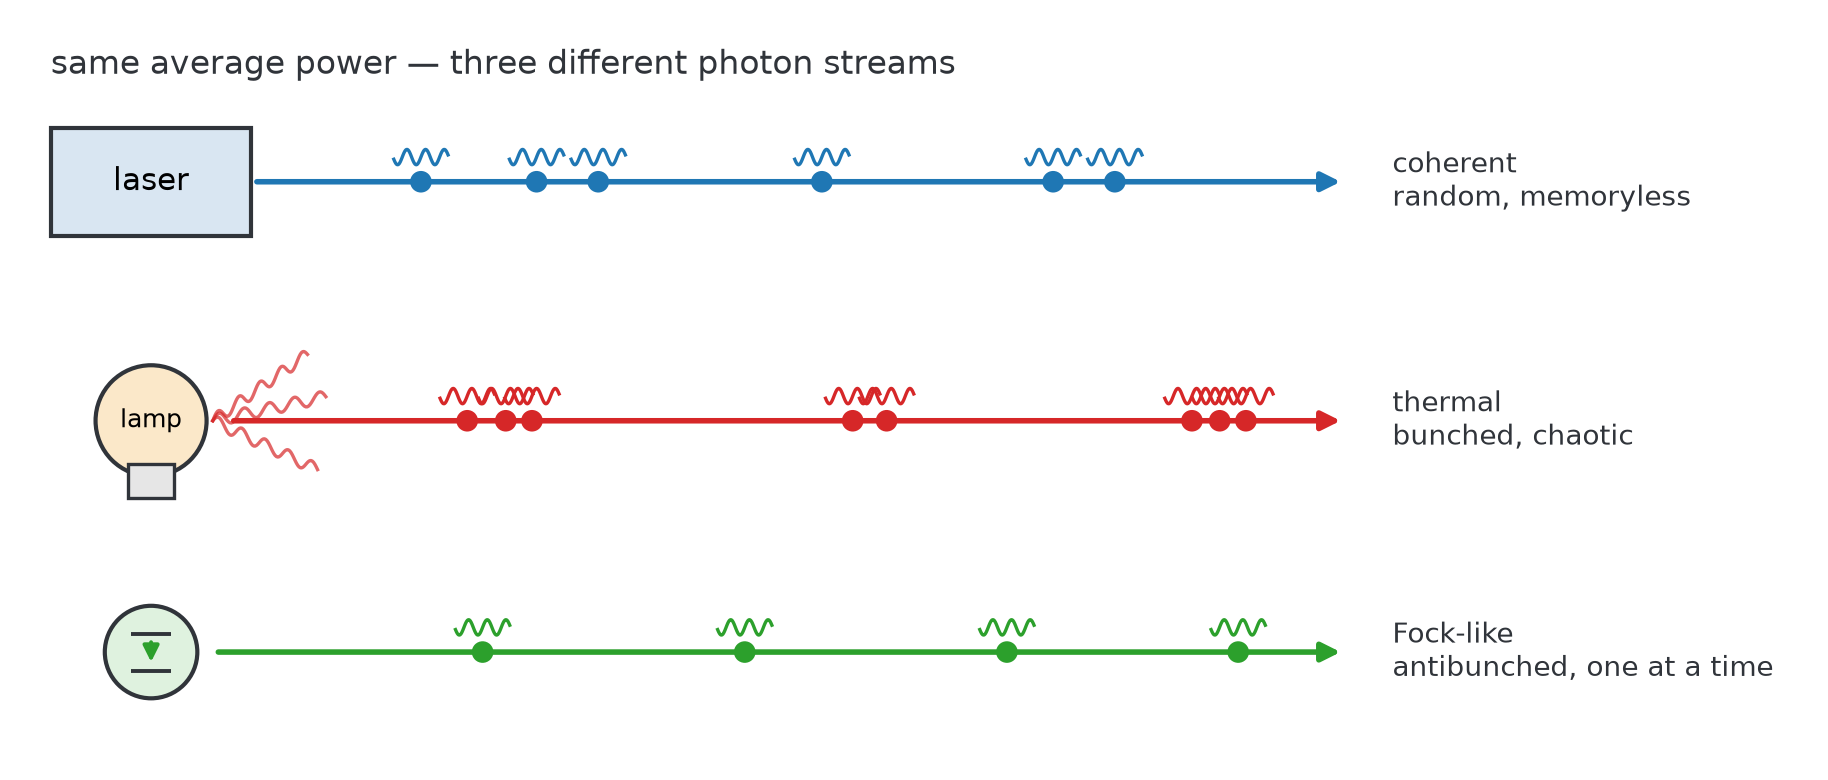

In [2]:
# Course sketch library (auto-fetches itself on Colab, where only
# this notebook exists; a no-op everywhere else).
import importlib.util, os, urllib.request
if importlib.util.find_spec("sketches") is None and not os.path.exists("sketches.py"):
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/laserlab/CountingPhotons"
        "/main/lectures/sketches.py", "sketches.py")
import sketches

sketches.three_sources()

## 2.1 · Shot noise in the real world

**What "shot noise" actually is.** Light of perfectly constant classical intensity still arrives as discrete, statistically independent photons. Independent random arrivals at a fixed average rate are the *definition* of a Poisson process — and for a Poisson distribution the variance equals the mean: $(\Delta N)^2 = \bar N$. The resulting $\sqrt{\bar N}$ jitter in every count is **shot noise**: the granularity (the "shot") of the beam itself, not a defect of the detector, and not removable by a better amplifier. (The name is Schottky's, 1918, for the identical effect with electrons in vacuum tubes.) It is the noise floor of every classical-light measurement — beatable only by changing the *statistics* of the light: $Q < 0$, or the squeezing of the next section.

So: Poissonian counting means $\Delta N = \sqrt{\bar N}$, so every intensity measurement with $\bar N$ detected photons has

$$\begin{gathered}\text{signal-to-noise ratio} \;\le\; \frac{\bar N}{\sqrt{\bar N}} = \sqrt{\bar N}\\[3pt]
\Longleftrightarrow\quad \text{relative noise} = \frac{1}{\sqrt{\bar N}} .\end{gathered}$$

That innocent square root runs half of experimental physics. Worked numbers:

| measurement | photons collected $\bar N$ | shot-noise floor $1/\sqrt{\bar N}$ |
|---|---|---|
| phone photo pixel, night mode | $\sim 10^2$ | **10%** — that's the grain you see |
| phone photo pixel, sunlight | $\sim 10^4$ | 1% — smooth |
| 1 mW laser pointer, 1 s integration | $2.7\times10^{15}$ | $2\times10^{-8}$ |
| fluorescence of *one* molecule, 1 ms bin | $\sim 10^2$ | 10% — single-molecule biophysics fights this daily |
| LIGO circulating beam, 10 ms | $\sim 10^{22}$ | $10^{-11}$ — and *still not good enough* (next section) |

Photon counting is one of the very few games where the noise floor is set by *how much light you collect*, not by your amplifier — and improving it means either **more photons** ($\sqrt{N}$: painful) or **better statistics than Poisson** ($Q<0$ or squeezing: quantum optics' sales pitch).

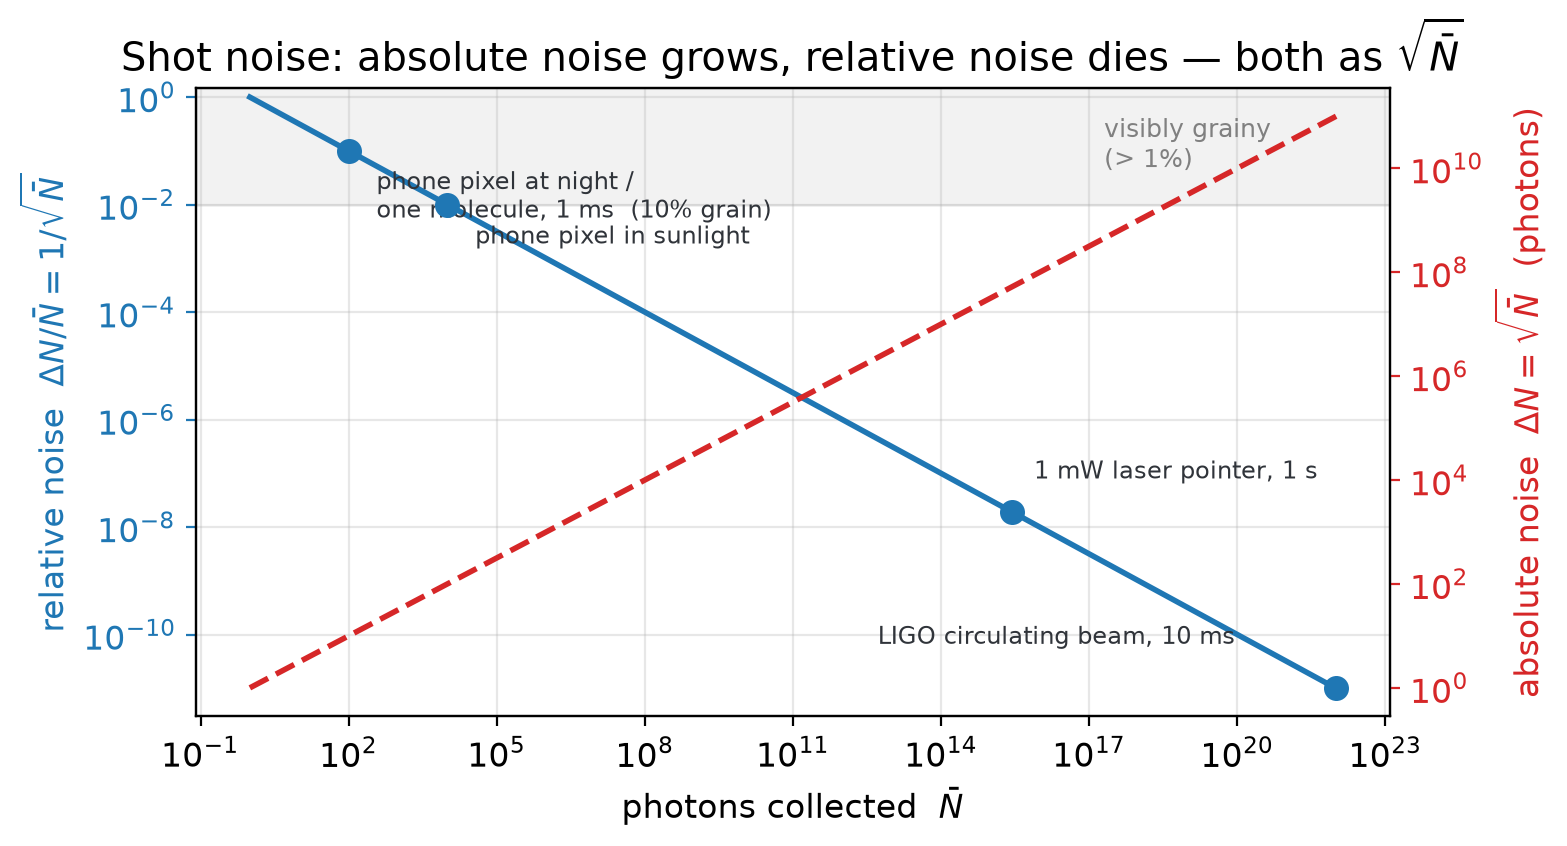

In [3]:
# One law, 22 orders of magnitude: shot noise vs collected photons.
Nbar = np.logspace(0, 22, 200)

fig, ax = plt.subplots(figsize=(8, 4.4))
ax.loglog(Nbar, 1 / np.sqrt(Nbar), color="tab:blue", lw=2)
ax.set_ylabel(r"relative noise  $\Delta N/\bar{N} = 1/\sqrt{\bar{N}}$",
              color="tab:blue")
ax.tick_params(axis="y", colors="tab:blue")
ax.set_xlabel(r"photons collected  $\bar{N}$")

ax2 = ax.twinx()
ax2.loglog(Nbar, np.sqrt(Nbar), color="tab:red", lw=2, ls="--")
ax2.set_ylabel(r"absolute noise  $\Delta N = \sqrt{\bar{N}}$  (photons)",
               color="tab:red")
ax2.tick_params(axis="y", colors="tab:red")
ax2.grid(False)

# the worked examples from the table
examples = [
    (1e2, "phone pixel at night /\none molecule, 1 ms  (10% grain)", (10, -24)),
    (1e4, "phone pixel in sunlight", (10, -14)),
    (2.7e15, "1 mW laser pointer, 1 s", (8, 12)),
    (1e22, "LIGO circulating beam, 10 ms", (-165, 16)),
]
for N_ex, label, off in examples:
    ax.plot(N_ex, 1 / np.sqrt(N_ex), "o", ms=8, color="tab:blue", zorder=5)
    ax.annotate(label, (N_ex, 1 / np.sqrt(N_ex)), textcoords="offset points",
                xytext=off, fontsize=8.5, color="#30343a")

ax.axhspan(0.01, 1.5, color="gray", alpha=0.10)
ax.text(2e17, 0.05, "visibly grainy\n(> 1%)", fontsize=9, color="gray")
ax.set_ylim(3e-12, 1.5)
ax.set_title("Shot noise: absolute noise grows, relative noise dies "
             r"— both as $\sqrt{\bar{N}}$")
plt.tight_layout()
plt.show()

# The 'huge variance' reading: LIGO's beam fluctuates by ~1e11 photons
# per measurement in ABSOLUTE terms - yet that is a relative error of
# 1e-11, the quietest measurement in this plot. Which axis matters is
# set by what you measure: fringe positions care about the relative one.

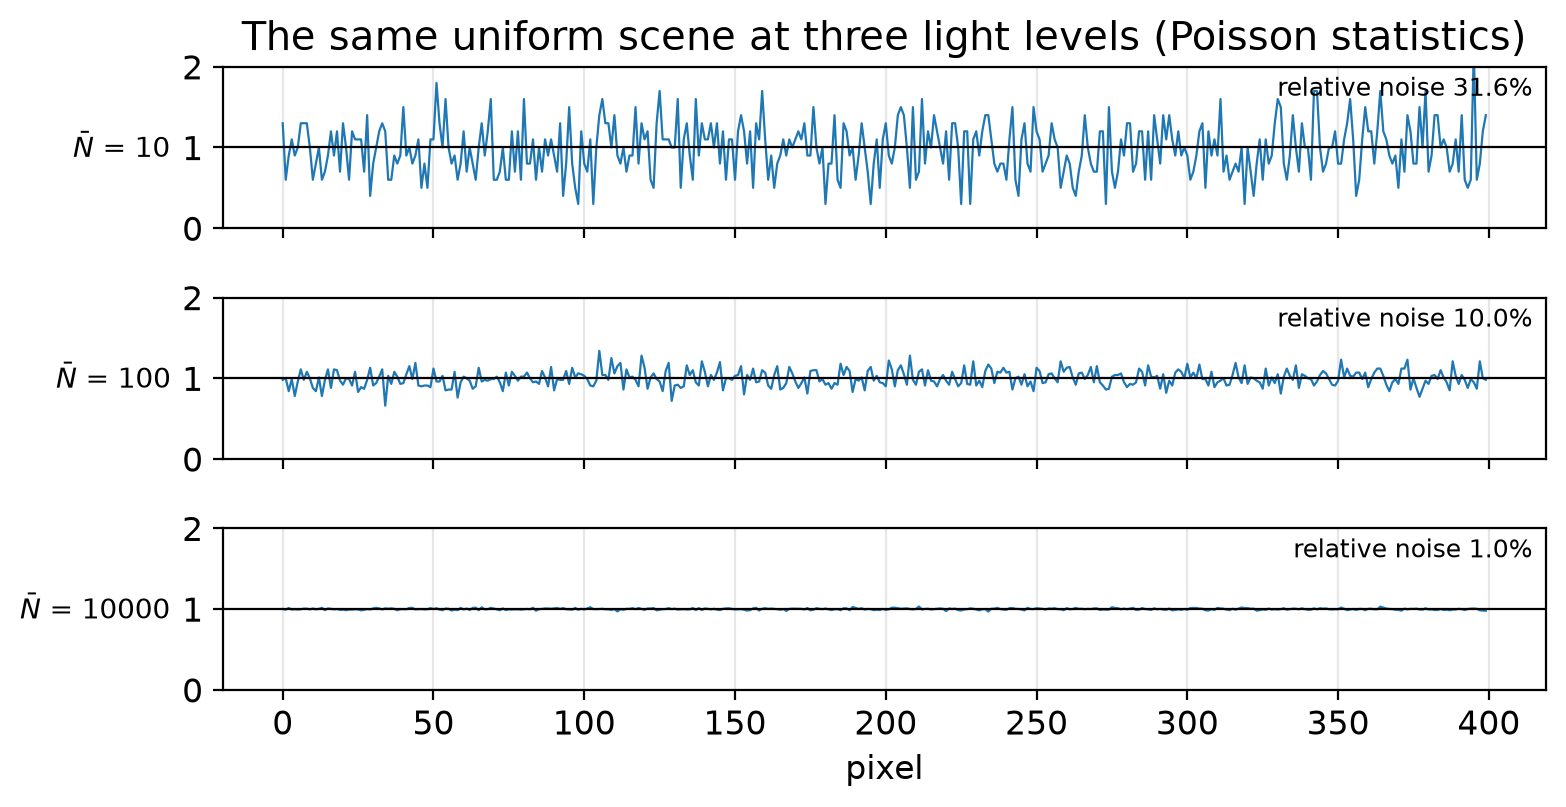

In [4]:
# Shot noise you have personally seen: photon counts across an 'image' row.
# A uniform gray scene photographed at three light levels.
pixels = 400
fig, axes = plt.subplots(3, 1, figsize=(8, 4.2), sharex=True)
for ax, Nbar in zip(axes, [10, 100, 10_000]):
    counts = rng.poisson(Nbar, pixels)
    ax.plot(counts / Nbar, lw=0.8)
    ax.axhline(1, color="k", lw=0.8)
    ax.set_ylim(0, 2)
    ax.set_ylabel(f"$\\bar N$ = {Nbar}", rotation=0, ha="right", va="center",
                  fontsize=10)
    ax.text(0.99, 0.82, f"relative noise {1/np.sqrt(Nbar):.1%}",
            transform=ax.transAxes, ha="right", fontsize=9)
axes[-1].set_xlabel("pixel")
axes[0].set_title("The same uniform scene at three light levels (Poisson statistics)")
plt.tight_layout()
plt.show()

## 2.2 · Case study: LIGO, the strong laser, and the vacuum that enters through the dark port

A gravitational-wave interferometer measures a *phase difference* between two 4 km arms. At the shot-noise limit, the phase uncertainty per measurement is

$$\Delta\varphi_{\rm shot} \simeq \frac{1}{\sqrt{\bar N}},$$

and LIGO needs $\Delta\varphi \sim 10^{-11}$ — displacement sensitivity of $10^{-18}$ m, a thousandth of a proton radius — to hear black holes collide [Abbott2016]. Hence design decision #1: **as strong a laser as the optics survive** — hundreds of kW circulating in the arms, because every factor 100 in power buys only a factor 10 in phase noise.

But brute force saturated. The next insight is pure quantum optics [Caves1981]: analyze *where the noise actually comes from*, and it is **not** the laser. The interferometer's beamsplitter has **two** input ports — the laser enters one, and the other, the "dark port"… is empty. Empty means **vacuum state**, and vacuum fluctuations ($\Delta X = \Delta P = 1/\sqrt2$, the last hour's section 1.2) enter there, beat against the laser field, and produce exactly the shot noise at the readout.

> **Back of the envelope — pinning the blame on the empty port.** Call the vacuum's quadrature jitter $\Delta X \sim 1$ (half a photon of zero-point fuzz; no phase — a round blob). The bright field acts as an amplifier for it: the beat at the readout multiplies the port's jitter by the local-oscillator amplitude $\sqrt{\bar N}$, giving count fluctuations $\sim\sqrt{\bar N}$ — shot noise — while the signal (mirrors rotating the bright field by $\varphi$) produces counts $\sim \bar N\varphi$. They cross at $\varphi \approx 1/\sqrt{\bar N} \approx 10^{-11}$ for $\bar N \approx 10^{22}$. And the smoking gun: the squeezed vacuum LIGO injects carries $\bar n = \sinh^2 r$ — a few photons per mode, femtowatts against 200 kW, some twenty-five orders of magnitude down — and it moves the noise floor of the whole machine [Tse2019]. The only knob that works is attached to the port with no light in it: the noise was never the laser's.
>
> *"But wait — $|0\rangle$ **is** a Fock state: sharp $n = 0$. Park a photon counter at that port and it will never click. Where is the noise?"* Exactly — and that is the resolution: the interferometer never counts the dark port on its own. It first interferes the port with the laser, and the beat reads out the port's **quadrature**, not its photon number. Sharp $n$ forces fuzzy $X$ (they don't commute): the vacuum has zero number noise and quadrature fluctuations worth $\hbar\omega/2$ of zero-point energy — the round disk of the last hour's phase-space triptych. And to be very clear: **no photon ever leaves the empty port.** There are no photons in $|0\rangle$ — every click at the readout is a *laser* photon; the port's fluctuating quadrature only decides how the laser's photons distribute between the two outputs. (Operator bookkeeping makes it compulsory: $\hat a_{\rm out} = \sqrt{T}\,\hat a_{\rm laser} + i\sqrt{R}\,\hat a_{\rm vac}$, and the vacuum term must be there — with zero photons but nonzero fluctuations — or $[\hat a, \hat a^\dagger] = 1$ breaks. The port contributes an *operator*, not photons.) The field fuzz itself is not a metaphor, by the way: electro-optic sampling with few-femtosecond gates has measured the vacuum's electric field directly in the time domain — zero mean, finite width, shot by shot, with no photon absorbed [Riek2015] — and two years later watched *squeezed* vacuum dip below the bare-vacuum band within a single optical cycle [Riek2017]. Round means phase-blind: the same noise lands in whichever quadrature the readout picks. Squeezing cannot remove that fuzz; it *reshapes the disk* so the thin direction faces the readout.
>
> *"Then inject a perfect $|1\rangle$ instead — zero number noise again!"* Tempting, and it makes things **worse**: a Fock state's quadrature variance is $(2n+1)\times$ the vacuum's in *every* direction — its Wigner ring sits *outside* the vacuum disk — so $|1\rangle$ at the dark port triples the variance the beat amplifies: $\sqrt3$ *more* phase noise. Zero noise in $n$ buys nothing at a port whose $n$ is never measured. The next section's demo shows exactly this, in numbers.
>
> *"Is the port really* vacuum, *though — isn't it thermal at 300 K?"* At optical frequencies, room temperature **is** the vacuum: $\bar n = 1/(e^{\hbar\omega/k_BT}-1)$ with $\hbar\omega/k_BT \approx 45$ at 1064 nm and 300 K gives $\bar n \approx e^{-45} \approx 10^{-20}$ thermal photons per mode — nothing. (The "thermal" curve in the noise budget is the *mirrors'* Brownian motion, mechanical, not thermal photons in the beam.) Run the same interferometer at 6 GHz and the port would hold $\bar n \sim 10^3$ thermal photons — which is exactly why microwave quantum optics lives in a dilution refrigerator at 10 mK: tomorrow morning's photons-per-mode story.

Caves' 1981 proposal: *replace* the vacuum at the dark port with **squeezed vacuum** — a state with $\Delta X < 1/\sqrt2$ in the measured quadrature (at the price of $\Delta P > 1/\sqrt2$, as Heisenberg collects his fee). Nothing about the laser changes; you improve the interferometer by upgrading *the state of nothing*.

It took ~30 years of squeezer engineering [Schnabel2017]; since 2019 LIGO and Virgo run with squeezed light injected into the dark port, gaining up to ~3 dB of sensitivity — a **40–50% increase in the expected detection rate** [Tse2019]. GEO600 holds the kilometer-scale record: 6.0 dB of quantum-noise reduction [Lough2021]. This is photon statistics as an astronomy instrument.

**Open-quantum-systems dictionary** (for this school's shared language): the interferometer is a system coupled to the *continuum of vacuum modes* — a zero-temperature bath. Shot noise is bath-induced noise entering through a specific port, and squeezing is **bath engineering**: you do not touch the system, you prepare the *environment* in a nonclassical state. You will meet the same move as "squeezed reservoirs" in the open-systems lectures of this school.

<p align="center"><img src="../figures/ligo_hanford.jpg" width="620" alt="LIGO Hanford aerial view"/></p>

*LIGO Hanford: 4 km of vacuum pipe per arm, hunting a phase shift of $10^{-11}$ rad. Photo: LIGO Laboratory, public domain.*

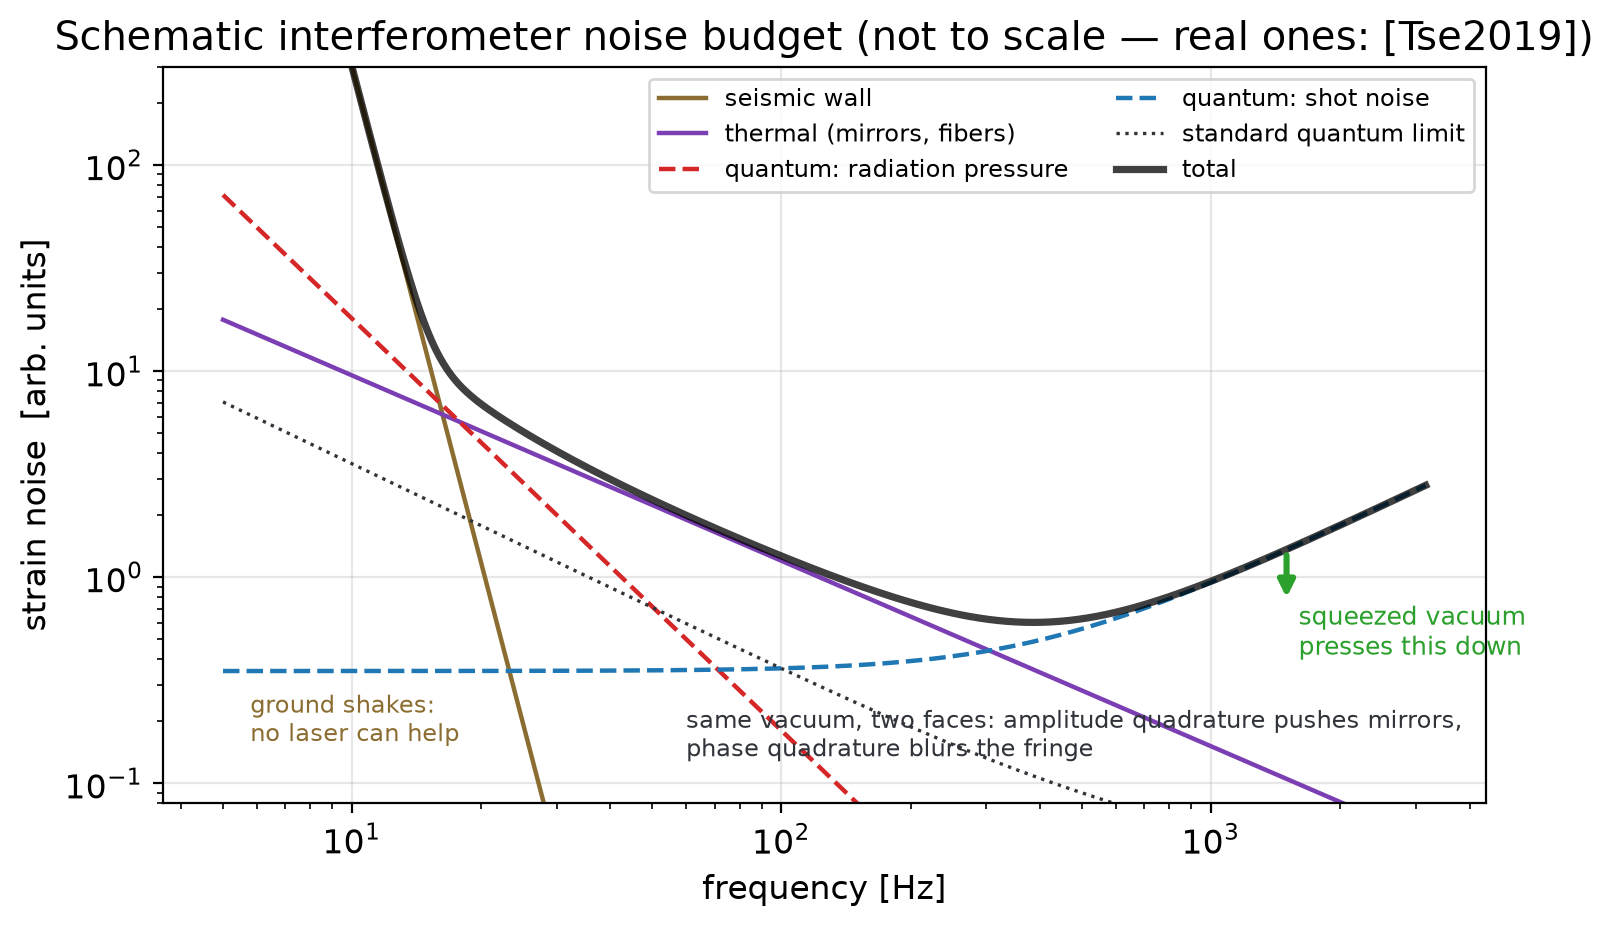

In [5]:
sketches.ligo_noise_budget()

How to read a noise budget (every gravitational-wave talk shows one): you live on the **bottom envelope**. Below ~20 Hz the ground itself is the wall — no light source fixes seismics. In the middle, thermal motion of mirror coatings and suspension fibers. And the two dashed curves are the stars of this lecture: **both are the same dark-port vacuum**, seen through its two quadratures. The *amplitude* quadrature physically kicks the 40 kg mirrors around (radiation pressure, dominating at low frequency); the *phase* quadrature blurs the fringe readout (shot noise, dominating at high frequency). Their crossing traces the **standard quantum limit**.

That duality is also squeezing's fine print: squeeze the phase quadrature and Heisenberg *pumps up* the amplitude one — the 2019 deployment [Tse2019] improved the shot-noise shoulder at the price of slightly worse radiation pressure at low frequency. The 2023 upgrade closed even that loophole with **frequency-dependent squeezing**: a 300 m filter cavity rotates the squeeze ellipse with frequency, so each band gets the quadrature it needs. Vacuum engineering, frequency by frequency.

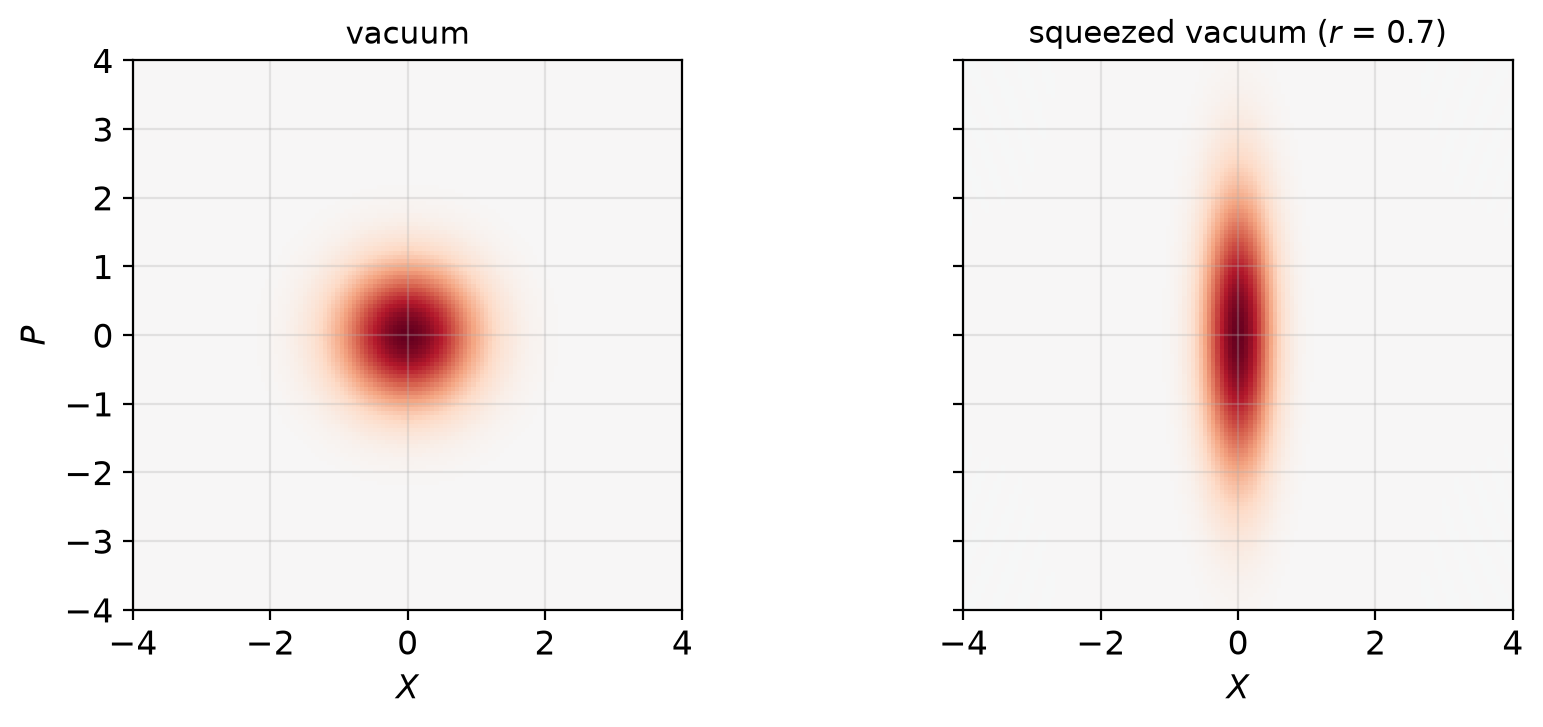

vacuum          : dX = 0.707, dP = 0.707, dX*dP = 0.500
squeezed vacuum : dX = 0.351, dP = 1.424, dX*dP = 0.500

P(n) of squeezed vacuum: [0.797 0.    0.146 0.    0.04  0.    0.012 0.   ]


In [6]:
# The state of nothing, upgraded: vacuum vs squeezed vacuum.
r = 0.7                                    # squeezing parameter (~6 dB)
vac = qutip.fock(N, 0)
sq_vac = qutip.squeeze(N, r) * vac         # squeezed vacuum state

fig, axes = plt.subplots(1, 2, figsize=(9, 3.8), sharey=True)
for ax, (label, st) in zip(axes, [("vacuum", vac),
                                  (f"squeezed vacuum ($r$ = {r})", sq_vac)]):
    W = qutip.wigner(st, xvec, xvec)
    vmax = np.abs(W).max()
    ax.pcolormesh(xvec, xvec, W, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("$X$")
    ax.set_aspect("equal")
    ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
axes[0].set_ylabel("$P$")
plt.tight_layout()
plt.show()

for label, st in [("vacuum          ", vac), ("squeezed vacuum ", sq_vac)]:
    dX = np.sqrt(qutip.variance(qutip.position(N), st))
    dP = np.sqrt(qutip.variance(qutip.momentum(N), st))
    print(f"{label}: dX = {dX:.3f}, dP = {dP:.3f}, dX*dP = {dX*dP:.3f}")

# Bonus fingerprint: squeezed vacuum contains only EVEN photon numbers -
# photons are born in pairs. Remember this on Wednesday (SPDC!).
P_sq = photon_number_distribution(sq_vac)[:8]
print("\nP(n) of squeezed vacuum:", np.array2string(P_sq, precision=3))

Two things to take away from the printout:

* the squeezed vacuum indeed has $\Delta X < \Delta X_{\rm vac}$ with $\Delta X\,\Delta P$ still $\ge \tfrac12$ — noise is *redistributed*, not destroyed;
* its $P(n)$ contains **only even photon numbers**: squeezed light is made of photon *pairs*. The two-mode version of this state is exactly what a down-conversion crystal emits — Wednesday we will herald single photons out of it.

*Three questions should be itching by now — **is a Fock state secretly squeezed? shouldn't LIGO run on Fock states, since they have no photon-number noise at all? and why has nobody ever noticed thermal statistics in daylight?** All three are the very next demos — predict the answers before the cells run.*

## 2.3 · Demo · The classic trap: "a Fock state is squeezed, right?"

You have just plotted Wigner functions — the perfect moment for the misconception the last hour left dangling.

A persistent misconception, worth killing with numbers: because Fock states are exotic and squeezed states are exotic, the two get conflated — *"a Fock state is a squeezed state"*. It is not. **Squeezed** means: noise in *some* quadrature **below the vacuum level** $\Delta X_{\rm vac} = 1/\sqrt2$. Compute the quadrature noise of every state we met today:

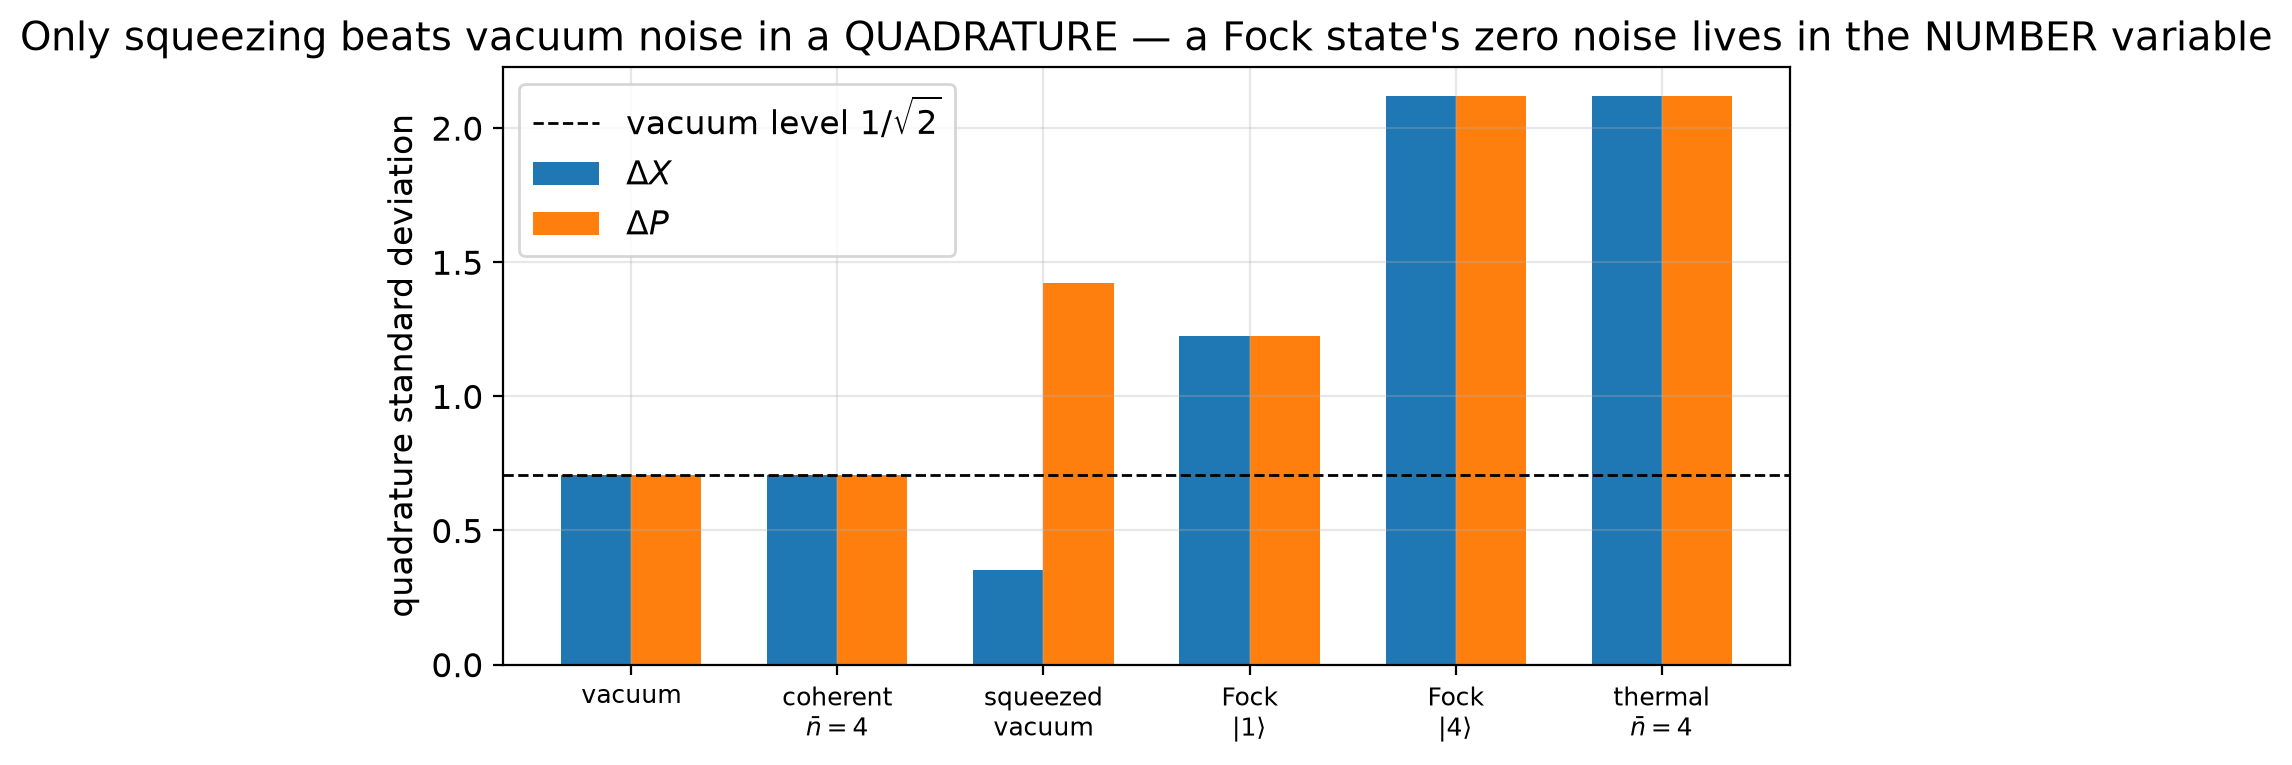

Fock |4>: dX = dP = 2.121 - identical to thermal nbar=4 (2.121)!


In [7]:
# Is anything here actually squeezed? Quadrature noise vs the vacuum level.
states_q = [("vacuum", qutip.fock(N, 0)),
            ("coherent\n" + r"$\bar{n}=4$", qutip.coherent(N, 2.0)),
            ("squeezed\nvacuum", qutip.squeeze(N, 0.7) * qutip.fock(N, 0)),
            ("Fock\n" + r"$|1\rangle$", qutip.fock(N, 1)),
            ("Fock\n" + r"$|4\rangle$", qutip.fock(N, 4)),
            ("thermal\n" + r"$\bar{n}=4$", qutip.thermal_dm(N, 4.0))]

x_op, p_op = qutip.position(N), qutip.momentum(N)
dX = [np.sqrt(qutip.variance(x_op, st)) for _, st in states_q]
dP = [np.sqrt(qutip.variance(p_op, st)) for _, st in states_q]

xpos = np.arange(len(states_q))
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.bar(xpos - 0.17, dX, 0.34, label=r"$\Delta X$", color="tab:blue")
ax.bar(xpos + 0.17, dP, 0.34, label=r"$\Delta P$", color="tab:orange")
ax.axhline(1 / np.sqrt(2), color="k", ls="--", lw=1,
           label=r"vacuum level $1/\sqrt{2}$")
ax.set_xticks(xpos, [n for n, _ in states_q], fontsize=9)
ax.set_ylabel("quadrature standard deviation")
ax.set_title("Only squeezing beats vacuum noise in a QUADRATURE — "
             "a Fock state's zero noise lives in the NUMBER variable")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Fock |4>: dX = dP = {dX[4]:.3f} - identical to thermal nbar=4"
      f" ({dX[5]:.3f})!")

Read the bars:

* only the **squeezed vacuum** dips below the dashed vacuum line — in one quadrature, paying for it in the other;
* **Fock states sit *above* vacuum noise in every quadrature**, $\Delta X = \Delta P = \sqrt{n + \tfrac12}$ — their Wigner rings lie *outside* the vacuum disk in all directions, with no preferred axis to squeeze along (a state of definite $n$ has no phase — the last hour's §1.4!). Their zero noise is real but lives in the *number* variable, $\Delta n = 0$ — a resource for counting-type measurements, invisible to any quadrature/phase readout;
* the punchline: $|4\rangle$ and the *thermal* state with $\bar n = 4$ have **identical quadrature noise** — second moments cannot tell our most quantum state from our most classical one.

So the two flagship non-classical states are non-classical in *orthogonal* ways:

| state | quadrature noise vs vacuum | Gaussian? | Wigner | non-classicality witness |
|---|---|---|---|---|
| coherent | equal | yes | positive | — (the classical reference) |
| thermal | above | yes | positive | — |
| **squeezed vacuum** | **below** (one axis) | yes | positive | sub-vacuum noise (2nd moments) |
| **Fock** | above (all axes) | **no** | **negative** | Wigner negativity (beyond 2nd moments) |

Squeezing lives entirely in second moments, so a **homodyne** measurement sees it (that is LIGO's detection chain). Fock-state quantumness is invisible to second moments — you need **photon counting** to see it. Two different windows into the quantum world; this course looks through the second one.

### The natural next question: why doesn't LIGO just use Fock states?

$\Delta n = 0$, $Q = -1$ — *no photon-number noise at all.* Shouldn't a Fock state be the ultimate interferometer fuel? Look at $|0\rangle, |1\rangle, |2\rangle$ in phase space before answering:

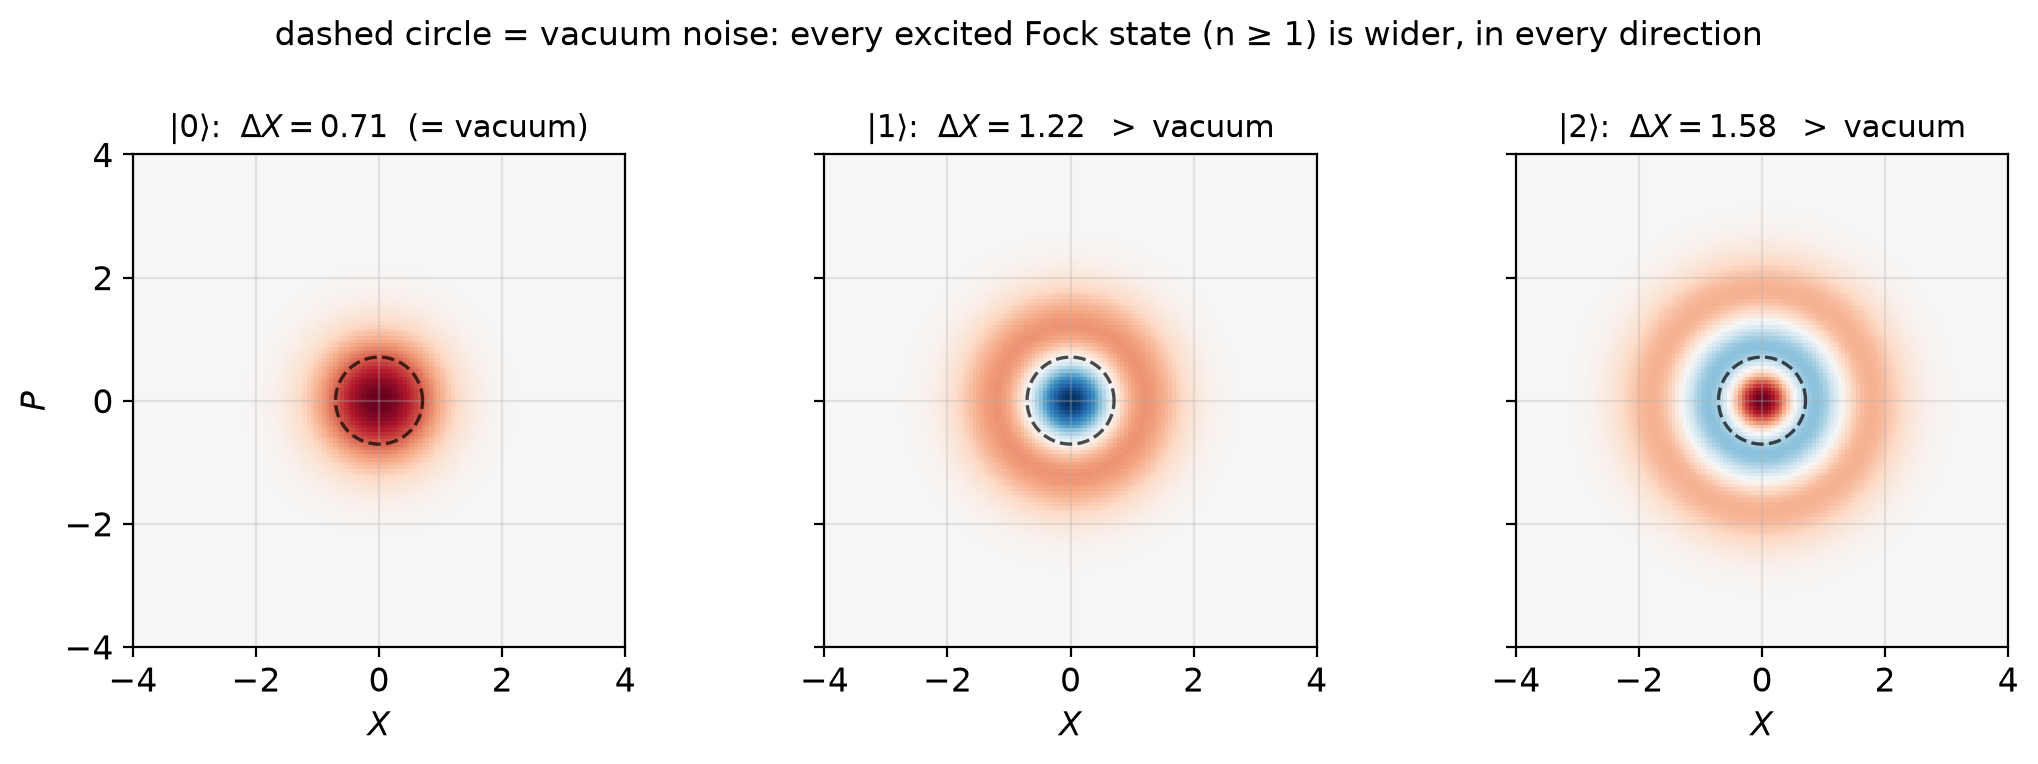

In [8]:
# The dark-port candidates: |0>, |1>, |2> in phase space.
fig, axes = plt.subplots(1, 3, figsize=(11, 3.6), sharey=True)
vac_r = 1 / np.sqrt(2)
for ax, n_f in zip(axes, [0, 1, 2]):
    st = qutip.fock(N, n_f)
    W = qutip.wigner(st, xvec, xvec)
    vmax = np.abs(W).max()
    ax.pcolormesh(xvec, xvec, W, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    # dashed circle: the vacuum quadrature width, for comparison
    th = np.linspace(0, 2 * np.pi, 100)
    ax.plot(vac_r * np.cos(th), vac_r * np.sin(th), "--", color="k",
            lw=1.2, alpha=0.7)
    dX = np.sqrt(qutip.variance(qutip.position(N), st))
    ax.set_title(rf"$|{n_f}\rangle$:  $\Delta X = {dX:.2f}$"
                 + ("  (= vacuum)" if n_f == 0 else "  $>$ vacuum"),
                 fontsize=11)
    ax.set_xlabel("$X$")
    ax.set_aspect("equal")
    ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
axes[0].set_ylabel("$P$")
fig.suptitle("dashed circle = vacuum noise: every excited Fock state "
             "(n ≥ 1) is wider, in every direction", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

Now the answers, one candidate at a time:

* **"Inject $|0\rangle$ into the dark port"** — congratulations, that is the *status quo*. The "empty" port is never empty: it already contains the vacuum state, and its $\Delta X = 1/\sqrt2$ fuzz **is** the shot noise (Caves' whole point). Mixing in more vacuum changes nothing.
* **"Inject $|1\rangle$ or $|2\rangle$"** — look at the rings: wider than the dashed vacuum circle in *every* direction ($\Delta X = \sqrt{n + \tfrac12}$). Injecting a Fock state makes the interferometer **noisier**. The readout is a *phase* measurement, and $\Delta n = 0$ is certainty in the wrong variable — number-definite states are exactly the ones with *no* phase. Shot noise in a fringe is *quadrature* noise, not photon-number noise; only a state with sub-vacuum noise in the measured quadrature helps, and rotationally symmetric states cannot have one. **Helping requires breaking the symmetry — that is what squeezing is.**
* **"Then run the whole interferometer on Fock light"** — this one is *almost* right, and Wednesday you will build it: interfering number states (the NOON state of Lab 5) picks up phase $N$ times faster, reaching the **Heisenberg limit** $1/N$ instead of shot noise's $1/\sqrt{N}$. The catch is subtler than "you can't make $10^{22}$" — that would be a strawman, because the *point* of Heisenberg scaling $1/N$ is that you would need far fewer photons: $N \sim 10^{11}$ would match LIGO's $10^{-11}$, eleven orders below what the laser carries. The real catches: (i) the largest number-entangled states ever prepared are $N \approx 5$ (NOON [Afek2010]) to a few tens (cavity Fock states) — still ten orders short; and (ii) number-state interferometry is fragile to loss — one absorbed photon poisons a NOON state, while squeezed light merely *degrades*, and there is a theorem waiting at the end of this notebook that makes the loss point precise. Squeezing is the loss-tolerant way to spend a quantum resource next to 200 kW of classical power. (Quantum advantage in optics is always a fight against loss — Wednesday's heralding lab is the same lesson from the other side.)



## 2.4 · Case study · Doing experimental physics better with quantum light

You now own every state in the toolbox — so let's use them on a real problem, the one from this hour: **measure a tiny length change** (LIGO's, or your own cavity's). Classical best effort: a coherent beam with $N$ detected photons gives $\Delta\varphi = 1/\sqrt{N}$, and after that you can only raise the power. Quantum optics offers **three different rulers**, and choosing between them is a masterclass in how quantum advantages live or die in a lab:

**Ruler 1 — keep the laser, squeeze the vacuum** *(the deployed one).* Attack the noise, not the signal: replace the dark-port vacuum with squeezed vacuum and win a **prefactor**, $e^{-r}/\sqrt{N}$ — the scaling stays $1/\sqrt N$ [Tse2019]. It coexists with hundreds of kW of circulating power, and loss merely shortens the win ($r_{\rm eff}$ shrinks; nothing breaks). Kilometer-scale record 6.0 dB [Lough2021]; since 2023, frequency-dependent squeezing delivers both quadratures at once [Ganapathy2023]. *Lesson: the cheapest quantum win is often in the port everyone thought was empty.*

**Ruler 2 — change the scaling** *(the seductive one).* Interfere number states and the phase accumulates $N$ times faster: the Heisenberg limit $1/N$ [Giovannetti2011]. NOON states do it (Wednesday's lab shows the doubled fringe), and you don't even need NOON's fragility — twin-Fock inputs $|N\rangle|N\rangle$ reach the same scaling more robustly [HollandBurnett1993]. Reality check, twice: the experimental record is $N = 5$ [Afek2010]; and the theorem that governs every proposal in this business — with *any* fixed loss, the asymptotic Heisenberg advantage collapses to a **constant factor** over shot noise [Demkowicz2012]. Read that twice: under loss, ruler 2's endgame is *a better prefactor* — which is exactly what ruler 1 already delivers, robustly, at any power. The bound is even quantitative, $\Delta\varphi \ge \sqrt{(1-\eta)/\eta}/\sqrt{N}$, and the paper's own worked example is GEO600: predicted maximal quantum enhancement factor 0.62 at its measured transmission $\eta = 0.62$, observed 0.67 — **the deployed squeezed-light detector already operates within a few percent of the fundamental lossy quantum limit** [Demkowicz2012]. Rulers 1 and 2 meet: squeezing is not just the practical choice, it is nearly all the quantum advantage that loss leaves on the table. *Lesson: scaling claims must survive the loss budget, and usually don't.*

**Ruler 3 — change the observable** *(the sly one).* If phase stability is your enemy, stop measuring phase. Broadband photon pairs lose their first-order fringes within femtoseconds — but the coherence doesn't vanish, it hides in $g^{(2)}$: the **HOM dip visibility** (Wednesday's lab) is a delay meter of **attosecond** accuracy — average 6 as, best 0.5 as, resolved with photons whose wavepackets are *tens of femtoseconds* long, four orders of magnitude coarser than the delays they measure — that needs *no* phase stabilization, and loss only costs event rate [Lyons2018]. (Their trick: sit at the Fisher-information-optimal point on the dip's *slope*, not its bottom, and let $10^9$ coincidences do the rest.) The fine print is subtler than "wrong observable": in a *medium* (glass, fiber, tissue) group delay and optical phase genuinely differ — but a gravitational wave is **not a medium**. It modulates the light travel time *achromatically* (spacetime is non-dispersive for light), so for a GW, phase delay $\equiv$ group delay [Saulson1997] and a time ruler is a legitimate GW readout in principle. What actually separates HOM timing from LIGO is **carrier gearing and flux**: a phase readout measures $\omega_{\rm opt}\,\delta\tau$ — a $\sim 10^{15}$ multiplier for free — and carries $10^{22}$ photons against MHz pair rates. Yet the counting route is live research: photon-counting readout of GW-band interferometers can beat homodyne for *detecting* weak non-Gaussian signals — the GQuEST experiment is being built on exactly that [GQuEST2025]. *Lesson: sometimes the quantum move is not a better state but a better question — and which question wins can change with the task.*

| ruler | improves | costs / fragility | status |
|---|---|---|---|
| squeezed vacuum | prefactor $e^{-r}$ | loss trims it gracefully | in production at LIGO/Virgo/GEO |
| number states | scaling $1/\sqrt N \to 1/N$ | loss voids the scaling [Demkowicz2012]; $N \le$ few | lab demonstrations |
| HOM visibility | phase stability not needed at all | no carrier gearing — flux-limited (for GWs, phase $\equiv$ group delay [Saulson1997]) | attosecond metrology; GW photon-counting proposals [GQuEST2025] |

The meta-lesson for your own experiments: **"use quantum" is not one strategy.** Ask what limits you — noise floor, scaling, or stability — and pick the resource whose *failure mode you can afford*. Tomorrow you measure the correlations behind ruler 3; Wednesday you build the states behind ruler 2 and watch loss eat them, quantitatively.

## 2.5 · Demo · Why nobody ever noticed (multimode washout)

Objection from the back row: *"Sunlight is thermal and my photodiode integrates sunlight — where is the Bose–Einstein distribution with its wild fluctuations?"*

Resolution: Bose–Einstein statistics hold **per mode**. A real detector integrates over $M$ modes — $M \approx \frac{\text{detection time}}{\text{coherence time}} \times \frac{\text{detection area}}{\text{coherence area}} \times 2$ polarizations. Sunlight has femtosecond coherence: even a 1 ns detector sees $M \sim 10^6$.

Summing $M$ independent thermal modes (total mean $\bar n$) gives the **negative binomial** distribution with

$$Q = \frac{\bar n}{M} \;\xrightarrow{\;M\to\infty\;}\; 0 .$$

The bunching washes out as $1/M$: thermal light *hides* its statistics from slow, fat detectors. (And as the source table later this hour repeats: even per mode, every lab source is only *approximately* thermal — the one emitter nature makes exactly thermal is a black hole [Hawking1975].) This is why nobody stumbled on photon bunching for 50 years — and why its discovery (HBT, 1956, with a narrowband mercury line and fast electronics — tomorrow's opening story) shocked the physics community.

*Quick estimate to discuss:* how many modes $M$ for (a) sunlight on a 100 ps-gated detector of 100 µm diameter, (b) a single-mode-fiber-coupled, 1 nm-filtered source on an SNSPD? For which could you hope to see bunching? — Keep $Q = \bar n/M$ in mind: it returns in tomorrow's Arecchi take-home as **ASE**.

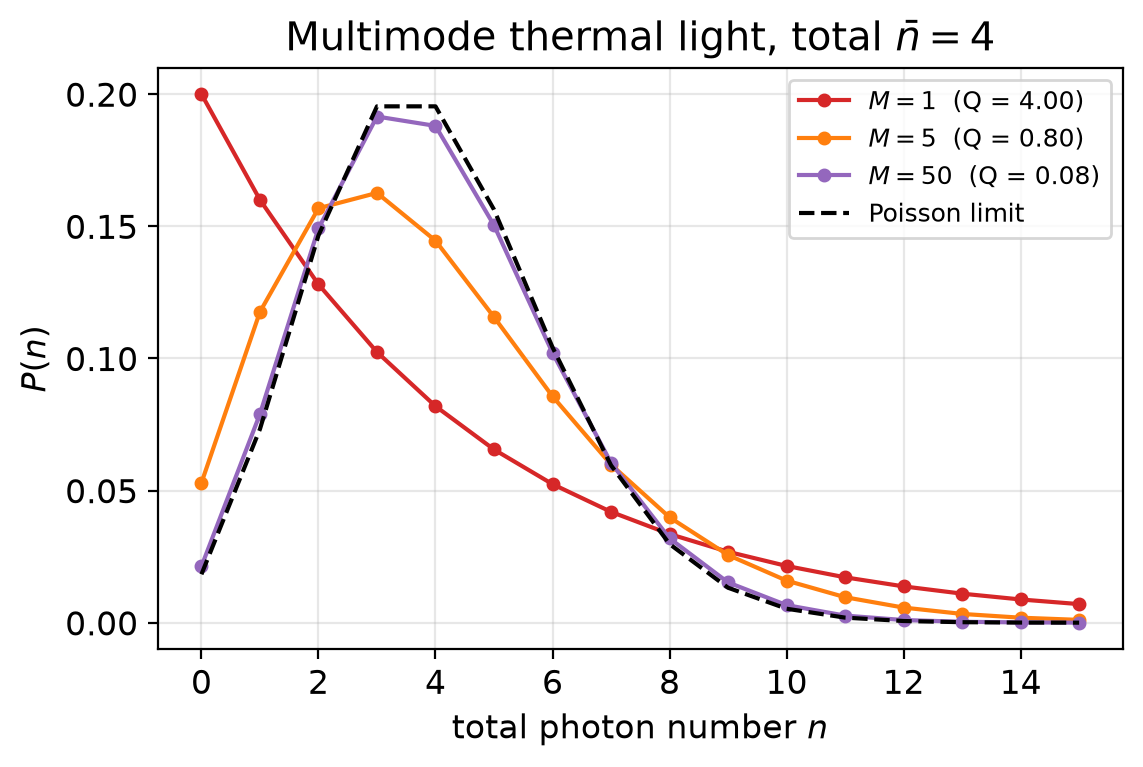

In [9]:
# Multimode thermal light: Bose-Einstein morphs into Poisson as M grows.
from scipy.special import comb, factorial

def negative_binomial_P(n: np.ndarray, nbar: float, M: int) -> np.ndarray:
    """P(n) for M equally bright thermal modes with total mean nbar."""
    x = nbar / M
    return comb(n + M - 1, n) * x**n / (1 + x)**(n + M)

n_axis = np.arange(16)
fig, ax = plt.subplots()
for M, color in [(1, "tab:red"), (5, "tab:orange"), (50, "tab:purple")]:
    ax.plot(n_axis, negative_binomial_P(n_axis, 4.0, M), "o-", ms=4,
            color=color, label=f"$M = {M}$  (Q = {4.0/M:.2f})")
ax.plot(n_axis, np.exp(-4.0) * 4.0**n_axis / factorial(n_axis), "k--",
        label="Poisson limit")
ax.set_xlabel("total photon number $n$")
ax.set_ylabel("$P(n)$")
ax.set_title(r"Multimode thermal light, total $\bar{n} = 4$")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

## 2.6 · What the detector actually sees: click streams

$P(n)$ is an abstraction — a photon counter produces a **stream of time tags**. A 2 ms simulated recording of our three sources (same average rate!); tomorrow you analyze exactly such data quantitatively.

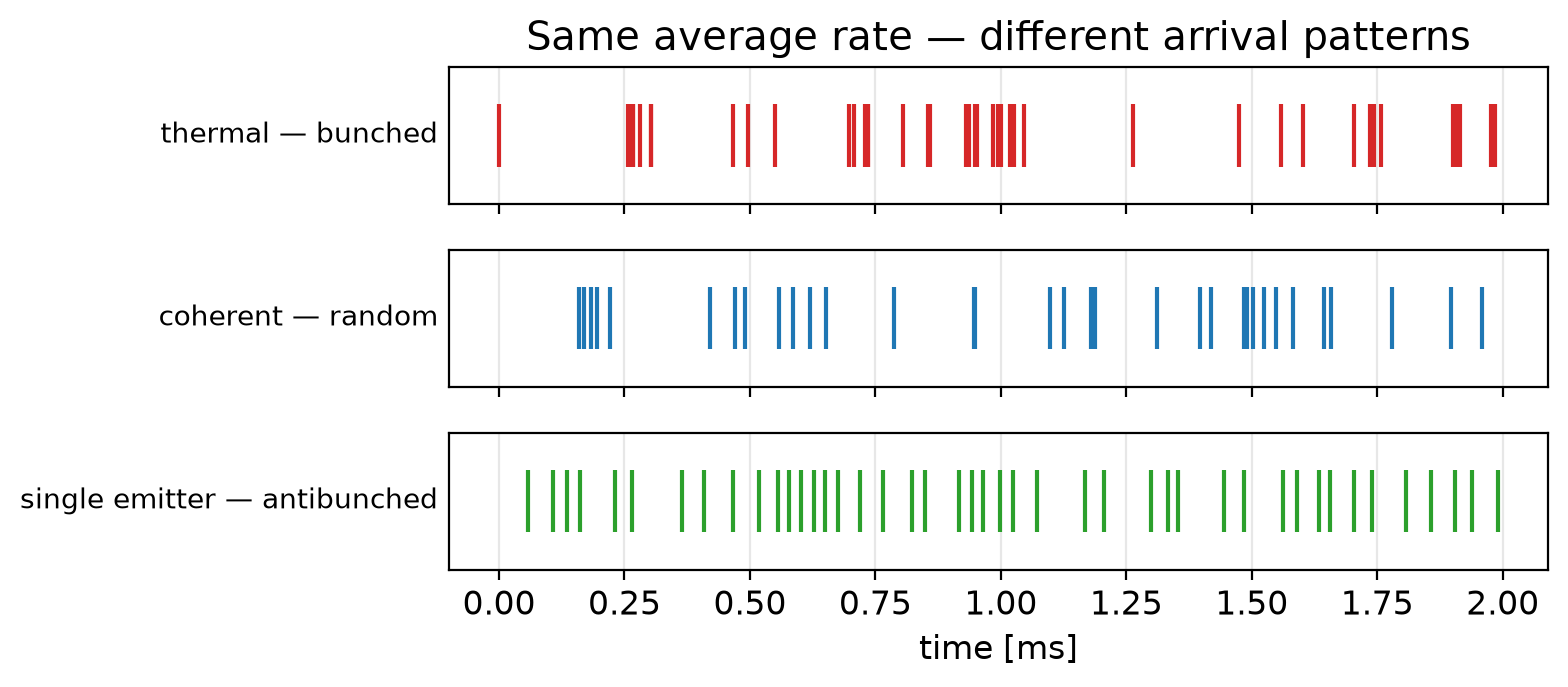

In [10]:
# Simulate 'click' arrival times (simplified versions of data/make_timetags.py).
rate = 20e3        # mean detected rate [clicks/s]
T_show = 2e-3      # displayed time window [s]

# coherent light: memoryless Poisson process
t_coherent = np.sort(rng.uniform(0, T_show, rng.poisson(rate * T_show)))

# thermal light: intensity fluctuates on the coherence time scale (bunching)
tau_c = 50e-6                                  # coherence time [s]
n_slots = int(T_show / tau_c)
intensity = rng.exponential(1.0, n_slots)      # single-mode thermal: I ~ exp
counts = rng.poisson(rate * tau_c * intensity)
t_thermal = np.sort(np.concatenate(
    [(k + rng.uniform(size=c)) * tau_c for k, c in enumerate(counts)]))

# single emitter: a dead time after every photon (antibunching)
gaps = 20e-6 + rng.exponential(1 / rate - 20e-6, int(3 * rate * T_show))  # 20 us dead time, mean gap 1/rate
t_emitter = np.cumsum(gaps)
t_emitter = t_emitter[t_emitter < T_show]

fig, axes = plt.subplots(3, 1, figsize=(8, 3.6), sharex=True)
for ax, (label, t, color) in zip(axes, [
        ("thermal — bunched", t_thermal, "tab:red"),
        ("coherent — random", t_coherent, "tab:blue"),
        ("single emitter — antibunched", t_emitter, "tab:green")]):
    ax.eventplot(t * 1e3, colors=color, linelengths=0.8)
    ax.set_yticks([])
    ax.set_ylabel(label, rotation=0, ha="right", va="center", fontsize=10)
axes[-1].set_xlabel("time [ms]")
axes[0].set_title("Same average rate — different arrival patterns")
plt.tight_layout()
plt.show()

Thermal clicks come in **clusters** (bunching), coherent clicks are **patternless**, and the single emitter keeps a minimum distance between clicks (**antibunching**) — it must be re-excited before it can emit again.

## 2.7 · Where do these states live in the lab?

| source | state | $Q$ | typical $\bar n$ per mode |
|---|---|---|---|
| laser above threshold | coherent | $0$ | anything you like |
| laser *at* threshold | partly thermal | $>0$ | Arecchi's 1965 counting experiment [Arecchi1965] |
| lamp, LED, star, ASE | thermal | $\bar n$ | $\ll 1$ (optical), $\gg 1$ (radio) |
| attenuated laser pulse | still coherent! | $0$ | $\sim 0.1$ (used in QKD) |
| squeezed vacuum (LIGO dark port) | pairs only, even $n$ | $>0$ (!) | $\ll 1$ |
| single atom / molecule / quantum dot / NV center | approx. $\lvert 1\rangle$ | $\to -1$ | $\le 1$ |
| heralded SPDC (→ Lecture 6) | $\lvert 1\rangle$, $\lvert 2\rangle$, … | $\to -1$ | $\le 1$ |

Two traps worth remembering:

* **Attenuating a laser never makes single photons.** Loss thins Poisson into sparser Poisson — $Q$ stays 0. A "0.1 photons per pulse" laser still has two-photon events; quantum key distribution had to invent decoy states because of this.
* **Thermal light doesn't mean "hot".** It means *chaotic*: many independent emitters with random phases. And strictly, every lab "thermal" source only *approximates* thermal statistics; arguably the only **exactly** thermal emitter nature provides is a black hole — the horizon guarantees a perfectly thermal spectrum [Hawking1975]. We meet the mechanism on Wednesday.

## 2.8 · How we compute: states and $P(n)$ in QuTiP

QuTiP [Lambert2026] represents a field mode in a **truncated** Fock space of dimension `N` — always check that your states fit well below the cutoff (rule of thumb: `N > nbar + 5*sqrt(nbar)`).

Three constructors do everything we need today:

```python
qutip.fock(N, n)             # Fock state |n>            (a ket)
qutip.coherent(N, alpha)     # coherent state |alpha>    (a ket)
qutip.thermal_dm(N, nbar)    # thermal state              (a density matrix!)
```

*This is the whole toolbox — everything this week builds on these three lines. The practice exercises that train it sit at the end of tomorrow's notebooks: [`03_Correlations_Generation_Detection`](03_Correlations_Generation_Detection.ipynb) closes with the Arecchi/ASE take-home, [`04_HandsOn_g2_HBT`](04_HandsOn_g2_HBT.ipynb) with five practice exercises (P1–P5). No deadline, sample solutions included — start any evening after tonight's setup.*

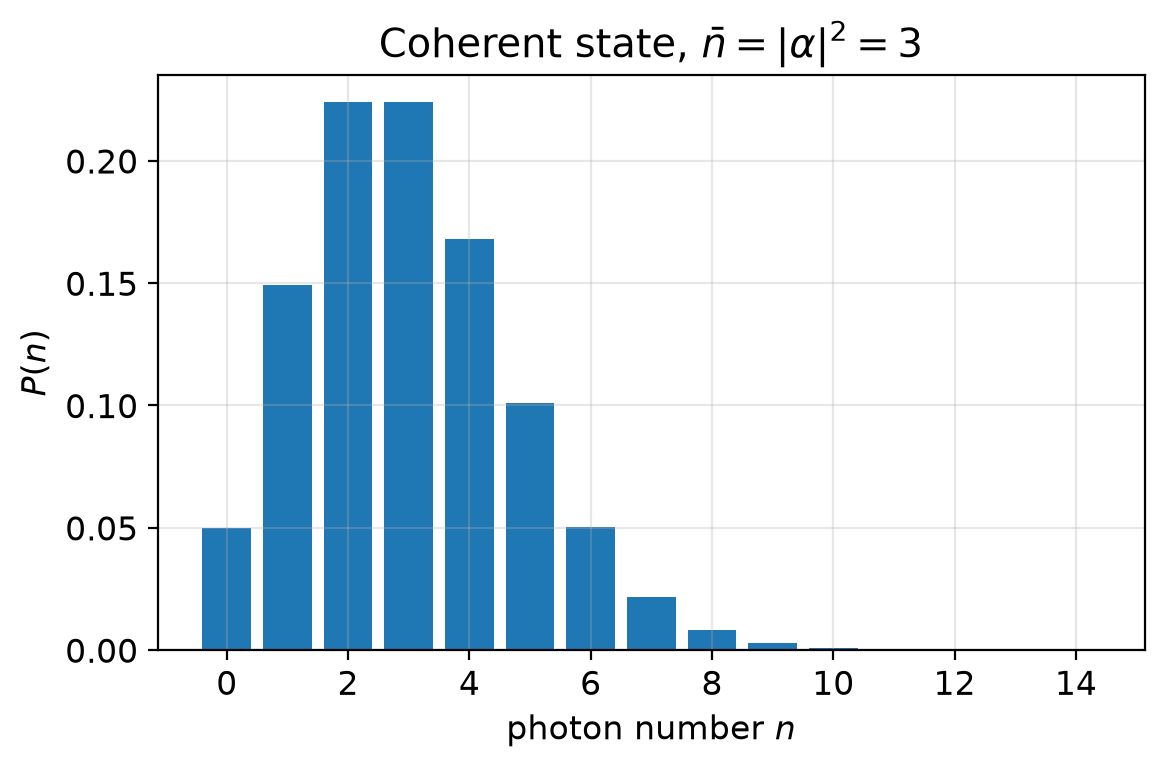

check: <n> = 3.0  (expected 3.0)


In [11]:
N = 100  # Fock-space cutoff. Thermal tails are long: too small a cutoff
         # biases the variance downward (try N = 30 and watch Q shrink!)

def photon_number_distribution(state) -> np.ndarray:
    """P(n) for a single-mode state (ket or density matrix).

    The photon number distribution is the diagonal of the density
    matrix in the Fock basis: P(n) = <n| rho |n>.
    """
    rho = qutip.ket2dm(state) if state.isket else state
    return np.real(rho.diag())

# Example: a coherent state with nbar = 3  ->  alpha = sqrt(3)
alpha = np.sqrt(3.0)
psi = qutip.coherent(N, alpha)
P = photon_number_distribution(psi)

plt.bar(np.arange(15), P[:15], color="tab:blue")
plt.xlabel("photon number $n$")
plt.ylabel("$P(n)$")
plt.title(r"Coherent state, $\bar{n} = |\alpha|^2 = 3$")
plt.tight_layout()
plt.show()

print("check: <n> =", np.sum(np.arange(N) * P).round(4), " (expected 3.0)")

## 2.9 · Check your understanding

1. Note the table above: squeezed vacuum has $Q > 0$ — super-Poissonian! — yet it is deeply non-classical (Wigner negativity in the two-mode version, LIGO improvement). Moral: $Q < 0$ is *sufficient* for non-classicality, not *necessary*. Which witness catches squeezed vacuum?
2. LIGO doubles its circulating power. By how much does the shot-noise-limited strain sensitivity improve? By what factor must injected squeezed vacuum reduce the phase-quadrature noise *variance* to achieve the same?
3. Your phone camera in sunlight collects *thermal* light, yet its pixel noise is pure shot noise. Estimate the number of modes $M$ one pixel integrates during a 1 ms exposure and the resulting $Q$. Roughly what detector speed would it take for the thermal excess to become visible — and which trick sidesteps that requirement entirely?

*Solutions open tomorrow's 9:00 lecture.*

---

## Tonight: the setup notebook

One thing before you leave: **tonight, work through [`00_Setup_GitHub_Codespaces.ipynb`](00_Setup_GitHub_Codespaces.ipynb)** — about 20 minutes, and the week's *only* evening task. It gets your Codespace (or the Colab fallback) running, so tomorrow's 10:30 hands-on session starts with everyone measuring, not troubleshooting.